# **TRAIN AND REGISTER A MACHINE LEARNING MODEL**

Lets train multiple machine learning models to select best one in order to predict which bank customers are likely to leave.
- Train Random Forest and LightGBM models.
- MLflow framework to log machine learning models, they used hyperaparameters and evaluation metrics.
- Register the MLmodel
- Assess the performance of the trained ML models on the validation dataset.

In [1]:
%pip install imblearn


StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 7, Finished, Available, Finished, True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 106.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 94.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 158.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Not uninstalling numpy at /home/trusted-service-user/cluster-env/trident_env/lib/python3.10/site-packages, outside environment /nfs4/pyenv-3f32de15-4914-42ef-a724-2c14c4dae6d7
    Can't uninstall 'numpy'. No files were found to uninstall.
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Not uninstalling scipy at /home/trusted-service-user/cluster-env/trident_env/lib/python3.10/site-packages, outside environment /nfs4/pyenv-3f32de15-4914-42ef-a724-2c14c4dae6d7
    Can't uninstall 'scipy'. No files were found to uninstall.
  Attempti

In [6]:
%pip install scikit-learn==1.6.1

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 27, Finished, Available, Finished, True)


[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



In [5]:
%pip install "mlflow==2.12.2"

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 21, Finished, Available, Finished, True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 104.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 54.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 134.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 40.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 78.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 24.7 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Not uninstalling typing-extensions at /home/trusted-service-user/cluster-env/trident_env/lib/python3.10/site-packages, outside environment /nfs4/pyenv-3f32de15-4914-42ef-a724-2c14c4dae6d7
    Can't uninstall 'typing_extensions'. No files were found to uninstall.
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully unin

In [8]:
import mlflow

print(mlflow.__version__)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 30, Finished, Available, Finished, False)

2.12.2


## LOAD THE DATA

In [9]:
import pandas as pd
SEED = 12345
df_clean = spark.read.format("delta").load("Tables/df_clean").toPandas()

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 31, Finished, Available, Finished, False)

## GENERATE EXPERIMENT FOR TRACKING AND LOGGING THE MODEL IN MLFLOW

In [10]:
import mlflow

EXPERIMENT_NAME = "bank-churn-experiment-SBM"

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 32, Finished, Available, Finished, False)

Autologging works by automatically capturing the values of input parameters and outputs metrics of a ML model as it is being trained.
This info is the logged to the workspace, where it can be accessed and visualized using ML FLOW APIs or the corresponding experiment in your workspace.

In [11]:
mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.autolog(exclusive=False)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 33, Finished, Available, Finished, False)

2026/05/31 15:15:26 INFO mlflow.tracking.fluent: Experiment with name 'bank-churn-experiment-SBM' does not exist. Creating a new experiment.


**Import scikit Learn and LightGBM**

In [12]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix, recall_score, roc_auc_score, classification_report

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 34, Finished, Available, Finished, False)

2026/05/31 15:15:38 WARNING mlflow.utils.autologging_utils: You are using an unsupported version of sklearn. If you encounter errors during autologging, try upgrading / downgrading sklearn to a supported version, or try upgrading MLflow.
2026/05/31 15:15:38 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/05/31 15:15:39 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.


**Prepare trainning, validation and test datasets**

In [13]:
y = df_clean['Exited']
print(y)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 35, Finished, Available, Finished, False)

0       1
1       1
2       1
3       1
4       1
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Exited, Length: 10000, dtype: int64


In [14]:
X = df_clean.drop('Exited', axis=1)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 36, Finished, Available, Finished, False)

In [15]:
print(X)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 37, Finished, Available, Finished, False)

      CreditScore  Geography_France  Geography_Germany  Geography_Spain  \
0             376             False               True            False   
1             819             False               True            False   
2             596             False              False             True   
3             640             False               True            False   
4             704              True              False            False   
...           ...               ...                ...              ...   
9995          607              True              False            False   
9996          538              True              False            False   
9997          579              True              False            False   
9998          784              True              False            False   
9999          680              True              False            False   

      Gender_Female  Gender_Male  Age  Tenure    Balance  NumOfProducts  \
0              True     

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state= SEED)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 38, Finished, Available, Finished, False)

In [17]:
print(X_test)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 39, Finished, Available, Finished, False)

      CreditScore  Geography_France  Geography_Germany  Geography_Spain  \
7867          649             False              False             True   
1402          708              True              False            False   
8606          460              True              False            False   
8885          620              True              False            False   
6494          771             False              False             True   
...           ...               ...                ...              ...   
2563          675             False              False             True   
1167          439              True              False            False   
1009          660             False               True            False   
1002          731             False               True            False   
694           656              True              False            False   

      Gender_Female  Gender_Male  Age  Tenure    Balance  NumOfProducts  \
7867           True     

****

**SAVE TEST DATA TO A DELTA TABLE**

In [18]:
table_name = "df_test"

df_test = spark.createDataFrame(X_test)
df_test.write.mode("overwrite").format("delta").save(f"Tables/{table_name}")
print(f"Spark test dataframe saved to delta table: {table_name}")

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 40, Finished, Available, Finished, False)

Spark test dataframe saved to delta table: df_test


## Apply SMOTE to the training data to synthesize new samples for teh minority class

Data exploration showed that out of the 10000 data points corresponding to 10000 customers, only 2000 have left the bank. This indicates that the dataset is highly imbalanced, this causes that there are too few examples of the minority class for a model to effectively learn the decisition boundary. SMOTE is the most widely used approach to synthesize new samples for the minority class.

SMOTE should only be applied to the training dataset. 

In [19]:
from collections import Counter
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = SEED)
X_res, y_res = sm.fit_resample(X_train, y_train)
new_train = pd.concat([X_res, y_res], axis=1)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 41, Finished, Available, Finished, False)

2026/05/31 15:16:51 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6f3a6528-031c-4eba-8ead-a5f9d9079e61', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/31 15:16:53 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/05/31 15:16:53 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/05/31 15:16:53 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/05/31 15:17:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/trusted-service-user/cluster-env/trident_env/lib/python3.10/site-packages/_dist

## **MODEL TRAINING**

### Train the model using Random Forest with maximum depth of 4 and 4 features

In [20]:
#Activate Autologging MLflow in order to register sklearn model
#This lets register automatically params, metrics...
mlflow.sklearn.autolog(registered_model_name='rfc1_sm') #register a trained model with name as rfc1_sm

# Define a Random Forest model with hyperparams
# max_depth=4 limits deepthness of trees 
# max_features=4 How many variables are considered in each divide 
# min_samples_split=3 3 samples to divide a node
# random_state=1 ensure reproducibility
rfc1_sm = RandomForestClassifier(
    max_depth=4,
    max_features=4,
    min_samples_split=3,
    random_state=1
)

# Start an experiment with name rfc1_sm
with mlflow.start_run(run_name="rfc1_sm") as run:

    # Save run_id of current experiment to identify and recovery model in the future
    rfc1_sm_run_id = run.info.run_id

    print("run_id: {}; status: {}".format(rfc1_sm_run_id, run.info.status))

    rfc1_sm.fit(X_res, y_res.ravel()) #Training model with balanced data, ravel() convert y_res to unidimensional array

    # Calculate accurancy of model with validation data
    rfc1_sm.score(X_val, y_val)

    # Generate predictions with validation data
    y_pred = rfc1_sm.predict(X_val)

    cr_rfc1_sm = classification_report(y_val, y_pred)

    cm_rfc1_sm = confusion_matrix(y_val, y_pred)

    # Calculamos el ROC AUC
    # predict_proba(X_res)[:, 1] obtiene la probabilidad de pertenecer a la clase positiva
    # OJO: aquí se calcula sobre X_res e y_res, es decir, sobre los datos balanceados de entrenamiento
    roc_auc_rfc1_sm = roc_auc_score(y_res, rfc1_sm.predict_proba(X_res)[:, 1])



StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 42, Finished, Available, Finished, False)

2026/05/31 15:17:38 WARNING mlflow.utils.autologging_utils: You are using an unsupported version of sklearn. If you encounter errors during autologging, try upgrading / downgrading sklearn to a supported version, or try upgrading MLflow.
2026/05/31 15:17:39 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/nfs4/pyenv-3f32de15-4914-42ef-a724-2c14c4dae6d7/lib/python3.10/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing 

run_id: f7bea407-3227-464f-a7d7-d79535023d44; status: RUNNING


Train the model using Random forest with maximum depth of 8 and 6 features

In [21]:
#Activate Autologging MLflow in order to register sklearn model
#This lets register automatically params, metrics...
mlflow.sklearn.autolog(registered_model_name='rfc2_sm') #register a trained model with name as rfc2_sm

# Define a Random Forest model with hyperparams
# max_depth=4 limits deepthness of trees 
# max_features=4 How many variables are considered in each divide 
# min_samples_split=3 3 samples to divide a node
# random_state=1 ensure reproducibility
rfc2_sm = RandomForestClassifier(
    max_depth=8,
    max_features=6,
    min_samples_split=3,
    random_state=1
)

# Start an experiment with name rfc1_sm
with mlflow.start_run(run_name="rfc2_sm") as run:

    # Save run_id of current experiment to identify and recovery model in the future
    rfc2_sm_run_id = run.info.run_id

    print("run_id: {}; status: {}".format(rfc2_sm_run_id, run.info.status))

    rfc2_sm.fit(X_res, y_res.ravel()) #Training model with balanced data, ravel() convert y_res to unidimensional array

    # Calculate accurancy of model with validation data
    rfc2_sm.score(X_val, y_val)

    # Generate predictions with validation data
    y_pred = rfc2_sm.predict(X_val)

    cr_rfc2_sm = classification_report(y_val, y_pred)

    cm_rfc2_sm = confusion_matrix(y_val, y_pred)

    # Calculamos el ROC AUC
    # predict_proba(X_res)[:, 1] obtiene la probabilidad de pertenecer a la clase positiva
    # OJO: aquí se calcula sobre X_res e y_res, es decir, sobre los datos balanceados de entrenamiento
    roc_auc_rfc2_sm = roc_auc_score(y_res, rfc2_sm.predict_proba(X_res)[:, 1])



StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 43, Finished, Available, Finished, False)

2026/05/31 15:18:56 WARNING mlflow.utils.autologging_utils: You are using an unsupported version of sklearn. If you encounter errors during autologging, try upgrading / downgrading sklearn to a supported version, or try upgrading MLflow.
2026/05/31 15:19:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/nfs4/pyenv-3f32de15-4914-42ef-a724-2c14c4dae6d7/lib/python3.10/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing 

run_id: 76f145eb-6693-4829-991a-0479caa6fab3; status: RUNNING


**Train the model using LightGBM**

In [22]:
mlflow.lightgbm.autolog(registered_model_name='lgbm_sm')
lgbm_sm_model = LGBMClassifier(
    learning_rate=0.07,
    max_delta_step = 2,
    n_estimators=100,
    max_depth=10,
    eval_metric = "logloss",
    objective='binary',
    random_state=42
)

with mlflow.start_run(run_name="lgbm_sm") as run:
    lgbm1_sm_run_id = run.info.run_id
    lgbm_sm_model.fit(X_res, y_res.ravel())
    y_pred = lgbm_sm_model.predict(X_val)
    accurancy = accuracy_score(y_val, y_pred)
    cr_lgbm_sm = classification_report(y_val, y_pred)
    cm_lgbm_sm = confusion_matrix(y_val, y_pred)
    roc_auc_lgbm_sm = roc_auc_score(y_res, lgbm_sm_model.predict_proba(X_res)[:,1])

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 44, Finished, Available, Finished, False)

2026/05/31 15:19:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/nfs4/pyenv-3f32de15-4914-42ef-a724-2c14c4dae6d7/lib/python3.10/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
Successfully registered model 'lgbm_sm'.


[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 4754, number of negative: 4754
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1148
[LightGBM] [Info] Number of data points in the train set: 9508, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leav

## **EXPERIMENTS ARTIFACT FOR TRACKING MODEL PERFORMANCE**

The experiment runs are automatucally saved in the experiment artifact. 

**Assess the performances of the trained models on the validation dataset**

Once done with ML training, it can assess the performance of trained models in two ways:

- Open saved experimnet from the workspace, load the machine learning models, and then assess performance of the loaded models on the validation dataset.

In [23]:
load_model_rfc1_sm = mlflow.sklearn.load_model(f"runs:/{rfc1_sm_run_id}/model")
load_model_rfc2_sm = mlflow.sklearn.load_model(f"runs:/{rfc2_sm_run_id}/model")
load_model_lgbm1_sm = mlflow.lightgbm.load_model(f"runs:/{lgbm1_sm_run_id}/model")

ypred_rfc1_sm_v1 = load_model_rfc1_sm.predict(X_val)
ypred_rfc2_sm_v1 = load_model_rfc2_sm.predict(X_val)
ypred_lgbm_sm_v1 = load_model_lgbm1_sm.predict(X_val)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 46, Finished, Available, Finished, False)

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).


StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 47, Finished, Available, Finished, False)

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 48, Finished, Available, Finished, False)

## **SHOW True/False Positive/Negtives using the confusion matrix**

In [24]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="tab10", rc={'figure.figsize':(9,6)})

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rc, rcParams
import numpy as np
import itertools

def plot_confusion_matrix(
    cm, classes, normalize = False, 
    title='Confusion Matrix',
    cmap=plt.cm.Blues):
    
    print(cm)
    plt.figure(figsize=(4,4))
    plt.rcParams.update({'font.size':10})
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, color="blue")
    plt.yticks(tick_marks, classes, color="blue")

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="red" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 49, Finished, Available, Finished, False)

2026/05/31 15:25:48 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.


Confusion matrix for Random Fores Classifier with maximum depth 4 and 4 features

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 50, Finished, Available, Finished, False)

[[1343  256]
 [ 162  239]]


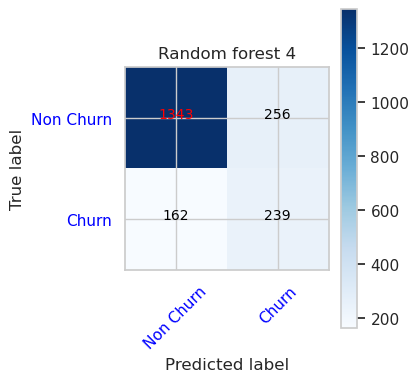

In [25]:
cfm = confusion_matrix(y_val, y_pred=ypred_rfc1_sm_v1)
plot_confusion_matrix(cfm, classes=['Non Churn', 'Churn'],
                     title='Random forest 4' )
tn, fp, fn, tp = cfm.ravel()

Confussion matrix for Random Forest 

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 51, Finished, Available, Finished, False)

[[1343  256]
 [ 162  239]]


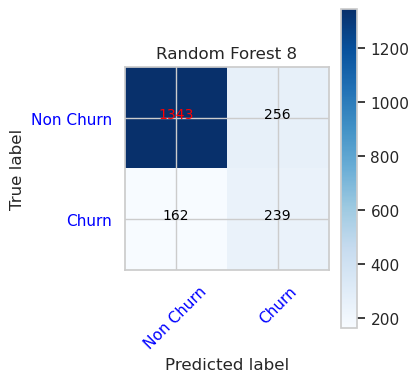

In [ ]:
cfm = confusion_matrix(y_val, y_pred=ypred_rfc2_sm_v1)

plot_confusion_matrix(cfm, classes=['Non Churn', 'Churn'],
                title='Random Forest 8')
tn, fp, fn, tp = cfm.ravel()

StatementMeta(, 3d776a00-6f10-4bbf-b7ef-3d8b2969b334, 52, Finished, Available, Finished, False)

[[1500   99]
 [ 200  201]]


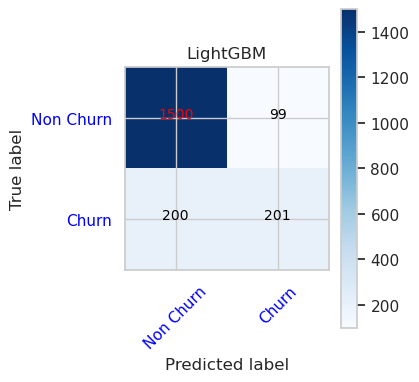

In [27]:
cfm = confusion_matrix(y_val, y_pred=ypred_lgbm_sm_v1)
plot_confusion_matrix(cfm, classes=['Non Churn', 'Churn'],
                    title = 'LightGBM')
tn, fp, fn, tp = cfm.ravel()